In [ ]:
import pandas as pd
import numpy as np
import sklearn as skl
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns


## TASK 3

### 1. Limpieza y pre-procesamiento

In [3]:
data = pd.read_csv("high_diamond_ranked_10min.csv")

data.head()


,gameId,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,...,redTowersDestroyed,redTotalGold,redAvgLevel,redTotalExperience,redTotalMinionsKilled,redTotalJungleMinionsKilled,redGoldDiff,redExperienceDiff,redCSPerMin,redGoldPerMin
0,4519157822,0,28,2,1,9,6,11,0,0,...,0,16567,6.8,17047,197,55,-643,8,19.7,1656.7
1,4523371949,0,12,1,0,5,5,5,0,0,...,1,17620,6.8,17438,240,52,2908,1173,24.0,1762.0
2,4521474530,0,15,0,0,7,11,4,1,1,...,0,17285,6.8,17254,203,28,1172,1033,20.3,1728.5
3,4524384067,0,43,1,0,4,5,5,1,0,...,0,16478,7.0,17961,235,47,1321,7,23.5,1647.8
4,4436033771,0,75,4,0,6,6,6,0,0,...,0,17404,7.0,18313,225,67,1004,-230,22.5,1740.4


In [4]:
data.columns

Index(['gameId', 'blueWins', 'blueWardsPlaced', 'blueWardsDestroyed',
       'blueFirstBlood', 'blueKills', 'blueDeaths', 'blueAssists',
       'blueEliteMonsters', 'blueDragons', 'blueHeralds',
       'blueTowersDestroyed', 'blueTotalGold', 'blueAvgLevel',
       'blueTotalExperience', 'blueTotalMinionsKilled',
       'blueTotalJungleMinionsKilled', 'blueGoldDiff', 'blueExperienceDiff',
       'blueCSPerMin', 'blueGoldPerMin', 'redWardsPlaced', 'redWardsDestroyed',
       'redFirstBlood', 'redKills', 'redDeaths', 'redAssists',
       'redEliteMonsters', 'redDragons', 'redHeralds', 'redTowersDestroyed',
       'redTotalGold', 'redAvgLevel', 'redTotalExperience',
       'redTotalMinionsKilled', 'redTotalJungleMinionsKilled', 'redGoldDiff',
       'redExperienceDiff', 'redCSPerMin', 'redGoldPerMin'],
      dtype='object')

In [5]:
corr_matrix = data.corr()
corr_matrix.style.background_gradient(cmap='coolwarm')

,gameId,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,blueHeralds,blueTowersDestroyed,blueTotalGold,blueAvgLevel,blueTotalExperience,blueTotalMinionsKilled,blueTotalJungleMinionsKilled,blueGoldDiff,blueExperienceDiff,blueCSPerMin,blueGoldPerMin,redWardsPlaced,redWardsDestroyed,redFirstBlood,redKills,redDeaths,redAssists,redEliteMonsters,redDragons,redHeralds,redTowersDestroyed,redTotalGold,redAvgLevel,redTotalExperience,redTotalMinionsKilled,redTotalJungleMinionsKilled,redGoldDiff,redExperienceDiff,redCSPerMin,redGoldPerMin
gameId,1.000000,0.000985,0.005361,-0.012057,-0.011577,-0.038993,-0.013160,-0.023329,0.016599,0.008962,0.015551,-0.007467,-0.033754,-0.040956,-0.040852,-0.002917,-0.004193,-0.014670,-0.012315,-0.002917,-0.033754,0.007405,-0.001197,0.011577,-0.013160,-0.038993,-0.008664,0.017296,0.017416,0.006163,0.003557,-0.010622,-0.012419,-0.021187,-0.005118,0.006040,0.014670,0.012315,-0.005118,-0.010622
blueWins,0.000985,1.000000,0.000087,0.044247,0.201769,0.337358,-0.339297,0.276685,0.221944,0.213768,0.092385,0.115566,0.417213,0.357820,0.396141,0.224909,0.131445,0.511119,0.489558,0.224909,0.417213,-0.023671,-0.055400,-0.201769,-0.339297,0.337358,-0.271047,-0.221551,-0.209516,-0.097172,-0.103696,-0.411396,-0.352127,-0.387588,-0.212171,-0.110994,-0.511119,-0.489558,-0.212171,-0.411396
blueWardsPlaced,0.005361,0.000087,1.000000,0.034447,0.003228,0.018138,-0.002612,0.033217,0.019892,0.017676,0.010104,0.009462,0.019725,0.034349,0.031719,-0.033925,0.010501,0.015800,0.027943,-0.033925,0.019725,-0.012906,0.115549,-0.003228,-0.002612,0.018138,-0.009009,-0.022817,-0.020121,-0.011964,-0.008225,-0.005685,-0.008882,-0.013000,-0.012395,0.001224,-0.015800,-0.027943,-0.012395,-0.005685
blueWardsDestroyed,-0.012057,0.044247,0.034447,1.000000,0.017717,0.033748,-0.073182,0.067793,0.041700,0.040504,0.016940,-0.009150,0.060054,0.060294,0.067462,0.111028,-0.023452,0.078585,0.077946,0.111028,0.060054,0.135966,0.123919,-0.017717,-0.073182,0.033748,-0.046212,-0.034509,-0.034439,-0.012712,-0.023943,-0.067467,-0.059090,-0.057314,0.040023,-0.035732,-0.078585,-0.077946,0.040023,-0.067467
blueFirstBlood,-0.011577,0.201769,0.003228,0.017717,1.000000,0.269425,-0.247929,0.229485,0.151603,0.134309,0.077509,0.083316,0.312058,0.177617,0.190365,0.125642,0.018190,0.378511,0.240665,0.125642,0.312058,-0.019142,-0.043304,-1.000000,-0.247929,0.269425,-0.201140,-0.141627,-0.135327,-0.060246,-0.069584,-0.301479,-0.182602,-0.194920,-0.156711,-0.024559,-0.378511,-0.240665,-0.156711,-0.301479
blueKills,-0.038993,0.337358,0.018138,0.033748,0.269425,1.000000,0.004044,0.813667,0.178540,0.170436,0.076195,0.180314,0.888751,0.434867,0.472155,-0.030880,-0.112506,0.654148,0.583730,-0.030880,0.888751,-0.034239,-0.092278,-0.269425,0.004044,1.000000,-0.020344,-0.224564,-0.207949,-0.104423,-0.082491,-0.161127,-0.412219,-0.462333,-0.472203,-0.214454,-0.654148,-0.583730,-0.472203,-0.161127
blueDeaths,-0.013160,-0.339297,-0.002612,-0.073182,-0.247929,0.004044,1.000000,-0.026372,-0.204764,-0.188852,-0.095527,-0.071441,-0.162572,-0.414755,-0.460122,-0.468560,-0.228102,-0.640000,-0.577613,-0.468560,-0.162572,0.008102,0.038672,0.247929,1.000000,0.004044,0.804023,0.163340,0.150746,0.076639,0.156780,0.885728,0.433383,0.464584,-0.040521,-0.100271,0.640000,0.577613,-0.040521,0.885728
blueAssists,-0.023329,0.276685,0.033217,0.067793,0.229485,0.813667,-0.026372,1.000000,0.149043,0.170873,0.028434,0.123663,0.748352,0.292661,0.303022,-0.062035,-0.134023,0.549761,0.437002,-0.062035,0.748352,-0.032474,-0.064501,-0.229485,-0.026372,0.813667,-0.007481,-0.182985,-0.189563,-0.058074,-0.060880,-0.133948,-0.356928,-0.396652,-0.337515,-0.160915,-0.549761,-0.437002,-0.337515,-0.133948
blueEliteMonsters,0.016599,0.221944,0.019892,0.041700,0.151603,0.178540,-0.204764,0.149043,1.000000,0.781039,0.640271,0.166644,0.239396,0.203530,0.232774,0.118762,0.198378,0.281464,0.263991,0.118762,0.239396,-0.017292,-0.005288,-0.151603,-0.204764,

In [6]:
cols = corr_matrix.columns
corr_values = corr_matrix.values  

cols_to_drop = []

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        corr = corr_values[i, j]  
        if corr < -0.95:
            col1 = cols[i]
            col2 = cols[j]
            is_mirror = (col1.startswith("blue") and col2.startswith("red")) or \
                        (col1.startswith("red") and col2.startswith("blue"))
            if is_mirror:
                # Elimina la red, mantén la blue
                if col1.startswith("red"):
                    cols_to_drop.append(col1)
                else:
                    cols_to_drop.append(col2)
                print(f"{col1} <-> {col2}: {corr:.3f}")

# Elimina todas las columnas red de una vez
data.drop(columns=cols_to_drop, inplace=True)
print(f"\nColumnas eliminadas: {cols_to_drop}")

blueFirstBlood <-> redFirstBlood: -1.000
blueGoldDiff <-> redGoldDiff: -1.000
blueExperienceDiff <-> redExperienceDiff: -1.000

Columnas eliminadas: ['redFirstBlood', 'redGoldDiff', 'redExperienceDiff']


### 2. Escalado y Support Vector Machines 

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score 

# SVM necesita escalado porque usa distancias euclidianas
# Variables con rangos grandes


X =data.drop(columns=["blueWins"], axis=1)
y = data["blueWins"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# SVM con kernel lineal
svm_linear = SVC(kernel="linear", C=1.0, random_state=42)
svm_linear.fit(X_train_scaled, y_train)
y_pred_linear = svm_linear.predict(X_test_scaled)

# SVM con kernel RBF
svm_rbf = SVC(kernel="rbf", C=1.0, gamma='scale', random_state=42)
svm_rbf.fit(X_train_scaled, y_train)
y_pred_rbf = svm_rbf.predict(X_test_scaled)

accuracy_linear = accuracy_score(y_test, y_pred_linear)
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)   

print("Accuracy SVM Linear:", accuracy_linear)
print("Accuracy SVM RBF:", accuracy_rbf)


Accuracy SVM Linear: 0.7302631578947368
Accuracy SVM RBF: 0.7196356275303644


### d. Análisis de Separabilidad Lineal

R//: El kernel lineal superó ligeramente al RBF, lo que indica que las partidas tienen separabilidad aproximadamente lineal. Las relaciones entre las variables (oro, kills, etc.) y la victoria son mayormente lineales, sin patrones no lineales complejos que valga la pena capturar.


## 3. Árboles de Decisión 

[Text(0.5, 0.9, 'blueGoldDiff <= 189.5\ngini = 0.5\nsamples = 7903\nvalue = [3966.0, 3937.0]\nclass = Red Wins'),
 Text(0.25, 0.7, 'blueGoldDiff <= -1523.0\ngini = 0.407\nsamples = 4188\nvalue = [2998, 1190]\nclass = Red Wins'),
 Text(0.375, 0.8, 'True  '),
 Text(0.125, 0.5, 'blueGoldDiff <= -3206.5\ngini = 0.276\nsamples = 2058\nvalue = [1718, 340]\nclass = Red Wins'),
 Text(0.0625, 0.3, 'blueGoldDiff <= -3946.5\ngini = 0.145\nsamples = 727\nvalue = [670.0, 57.0]\nclass = Red Wins'),
 Text(0.03125, 0.1, '\n  (...)  \n'),
 Text(0.09375, 0.1, '\n  (...)  \n'),
 Text(0.1875, 0.3, 'blueEliteMonsters <= 0.5\ngini = 0.335\nsamples = 1331\nvalue = [1048, 283]\nclass = Red Wins'),
 Text(0.15625, 0.1, '\n  (...)  \n'),
 Text(0.21875, 0.1, '\n  (...)  \n'),
 Text(0.375, 0.5, 'blueExperienceDiff <= -713.5\ngini = 0.48\nsamples = 2130\nvalue = [1280, 850]\nclass = Red Wins'),
 Text(0.3125, 0.3, 'blueDeaths <= 10.5\ngini = 0.44\nsamples = 861\nvalue = [580, 281]\nclass = Red Wins'),
 Text(0.28125,

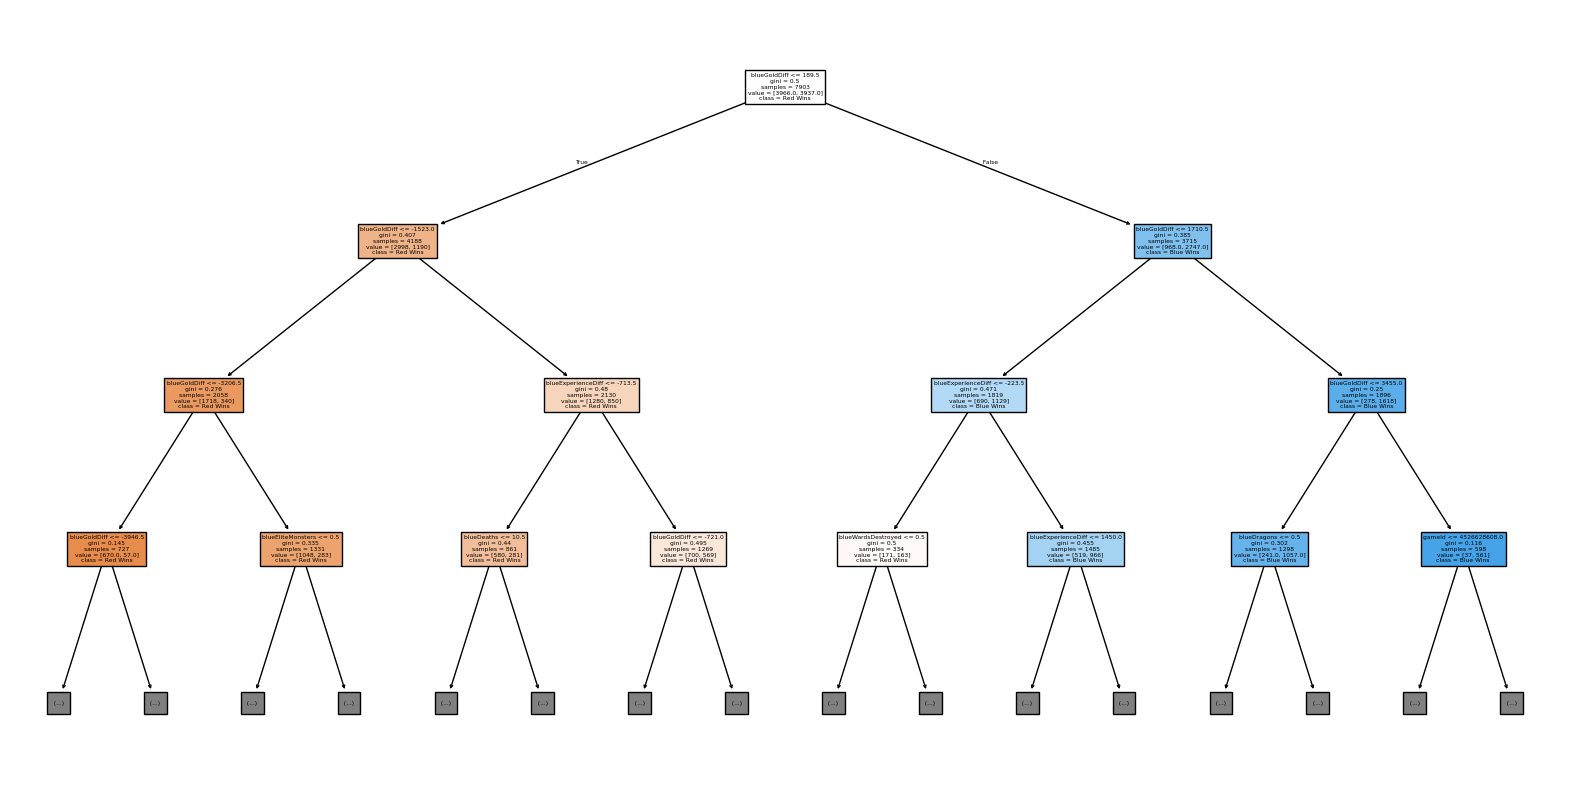

In [13]:
from sklearn.tree import DecisionTreeClassifier, plot_tree


dt_classifier = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_classifier.fit(X_train, y_train)

y_pred_dt = dt_classifier.predict(X_test)

# accuracy
accuracy_dt = accuracy_score(y_test, y_pred_dt)


# Visualización del árbol
plt.figure(figsize=(20,10))
plot_tree(dt_classifier, feature_names=X.columns.tolist(), class_names=["Red Wins", "Blue Wins"], filled=True, max_depth=3)

                        Feature  Importance
16                 blueGoldDiff    0.896184
17           blueExperienceDiff    0.033996
8                   blueDragons    0.009760
33  redTotalJungleMinionsKilled    0.009201
7             blueEliteMonsters    0.007903


C:\Users\djlop\AppData\Local\Temp\ipykernel_19812\3459276758.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=top5, palette="viridis")


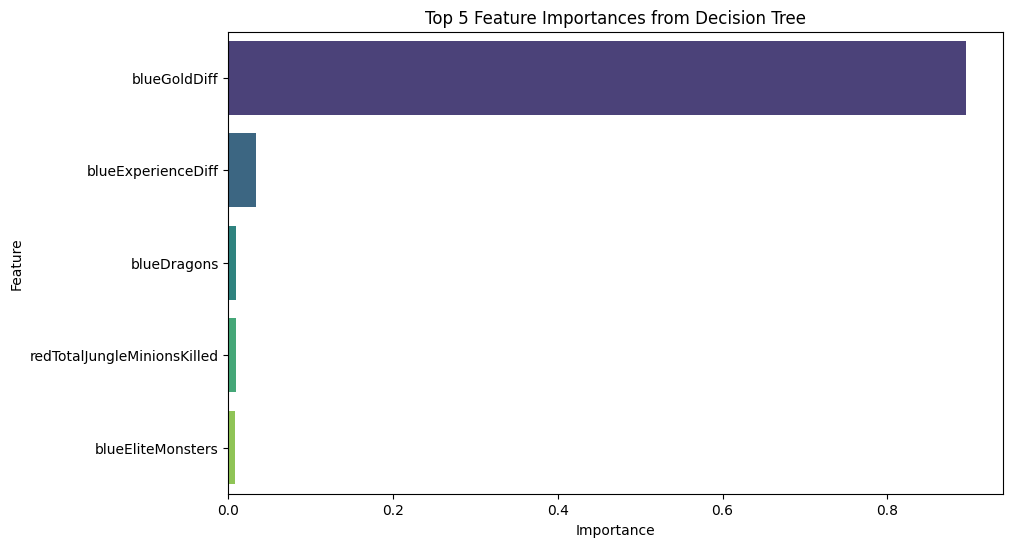

In [14]:
importances = dt_classifier.feature_importances_
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

top5 = importance_df.head(5)
print(top5) 

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=top5, palette="viridis")
plt.title("Top 5 Feature Importances from Decision Tree")
plt.xlabel("Importance")
plt.show()



### c. Análisis de Feature Importance

Las top 5 variables más importantes son:
1. **blueGoldDiff** (90%): Dominante. La diferencia de oro es el mejor predictor.
2. **blueExperienceDiff** (3%): La experiencia también importa.
3. **blueDragons**: Controlar dragones da ventaja.
4. **redTotalJungleMinionsKilled**: Información del enemigo (posible data leakage).
5. **blueEliteMonsters**: Objetivos elite (Herald, Baron).

**¿Esto tiene sentido?** Sí. En LoL, la diferencia de oro es el indicador más fuerte de ventaja, seguido por experiencia y control de objetivos (dragones). Esto coincide con la estrategia del juego.

In [15]:
print("=== Comparación de Modelos ===")
print(f"SVM Lineal:        {accuracy_linear:.4f}")
print(f"SVM RBF:           {accuracy_rbf:.4f}")
print(f"Decision Tree:     {accuracy_dt:.4f}")

=== Comparación de Modelos ===
SVM Lineal:        0.7303
SVM RBF:           0.7196
Decision Tree:     0.7232


### 4. Comparación

##### a. Mejor desempeño cuantitativo
- El SVM lineal, obtuvo  el mejor acurracy con 73.03%
#### b. SVM vs Árboles de Decisión

Usaría el decision tree (a pesar de tener accuracy ligeramente menor) por:

1. **Interpretabilidad**: Ya que el árbol muestra reglas claras ("Si goldDiff > 500, entonces...") 
2. **Visualizable**: Se puede ver gráficamente el proceso de decisión
3. **Explicable**: Puedes decir exactamente qué factores causaron la victoria
4. **Feature Importance**: Muestra qué variables importan más (oro, experiencia, dragones)
